In [1]:
"""
Burst_simulation_spectrogram.ipynb
Lukasz Radzinski
Charite Neurophysics Group, Berlin
Script for spectrogram analysis
of simulated burst
"""

'\nBurst_simulation_spectrogram.ipynb\nLukasz Radzinski\nCharite Neurophysics Group, Berlin\nScript for spectrogram analysis\nof simulated burst\n'

In [2]:
import os
import sys
import meet
import scipy
import numpy as np
from tqdm import trange
import matplotlib.pyplot as plt
from scipy import signal as sig
from BurstModel import BurstModel
import matplotlib.ticker as plticker
import helper_scripts.helper_functions as helper_functions


# set global parameters for plots

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600
#plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
#plt.rcParams['axes.ymargin'] = 0.01
#plt.rcParams['axes.xmargin'] = 0.01

2026-02-09 17:30:47.616818: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 17:30:47.637786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# general settings

# select subject [S1-S5]
subject = 'S1'

additional_file_info = ''
additional_title_info = ''

data_input_folder = '../Data/cleaned_data'
plots_output_folder = '../Results/burst_simulation_spectrogram'

additional_plot_title = ''

srate = 20000

meg_unit = 'B [fT]'
meg_asd_unit = '[fT/√Hz]'

In [4]:
# add header to the plot
def plt_header(main_title='', use_suptitle = False, fontsize=12):

    title = main_title
    
    if(use_suptitle):
        plt.suptitle(title, fontsize=fontsize)
    else:
        plt.title(title, fontsize=fontsize)

In [5]:
# show and save the plot
def plt_show_save_fig(fig_name=None):

    if(fig_name):
        fig_name += '.png'
    else:
        plt_show_save_fig.counter += 1
        fig_name = 'fig%02d.png' % plt_show_save_fig.counter

    print('--------------------\n'+fig_name)
    os.makedirs(plots_output_folder, exist_ok=True)
    plt.savefig(os.path.join(plots_output_folder, fig_name), bbox_inches='tight')
    plt.show()

plt_show_save_fig.counter = 0

In [6]:
# load MEG and marker data

meg_data_file = os.path.join(data_input_folder, subject+'.npy')
meg_stim_data = np.load(meg_data_file)

meg_data = meg_stim_data[0]
marker = meet.getMarker(meg_stim_data[-1])

In [7]:
sigma_freq_range_subj = {}

sigma_freq_range_subj['S1'] = [400, 900]
sigma_freq_range_subj['S2'] = [400, 900]
sigma_freq_range_subj['S3'] = [450, 950]
sigma_freq_range_subj['S4'] = [450, 950]
sigma_freq_range_subj['S5'] = [450, 950]

sigma_freq_range = sigma_freq_range_subj[subject]

In [8]:
meg_data_hilb = sig.hilbert(meg_data)

sigma_fir_coeffs = sig.firwin(303, sigma_freq_range, pass_zero=False, fs=srate)
meg_sigma_data = sig.filtfilt(sigma_fir_coeffs, 1.0, meg_data_hilb)

In [9]:
burst_win_ms_subj = {}
burst_win_ms_subj['S1'] = [13, 33]
burst_win_ms_subj['S2'] = [13, 28]
burst_win_ms_subj['S3'] = [13, 28]
burst_win_ms_subj['S4'] = [13, 25]
burst_win_ms_subj['S5'] = [10, 30]

burst_win_ms = burst_win_ms_subj[subject]

In [10]:
medium_win_ms = [0,100]
medium_win_samples = np.round(np.array(medium_win_ms)/1000.*srate).astype(int)
sigma_medium_trials = meet.epochEEG(meg_sigma_data, marker, medium_win_samples)
data_t_medium_ms = np.linspace(medium_win_ms[0], medium_win_ms[1], sigma_medium_trials.shape[-2]+1)[:-1]

burst_win_samples = np.round(np.array(burst_win_ms)/1000.*srate).astype(int)
sigma_burst_trials = meet.epochEEG(meg_sigma_data, marker, burst_win_samples)
data_t_burst_ms = np.linspace(burst_win_ms[0], burst_win_ms[1], sigma_burst_trials.shape[-2]+1)[:-1]

In [11]:
# calculate indices in medium trials that correspond to the sigma burst time window

burst_mt_smpl = [np.nonzero(data_t_medium_ms == burst_win_ms[0])[0][0],
              np.nonzero(data_t_medium_ms == burst_win_ms[1])[0][0]]
burst_mt_smpl = np.array(burst_mt_smpl)

# set simulated burst offset position in relation the physiological burst
sigma_sim_offset_ms = 30
burst_sim_mt_smpl = np.array(burst_mt_smpl)+sigma_sim_offset_ms*srate//1000
data_t_burst_sim_ms = data_t_burst_ms + sigma_sim_offset_ms

In [12]:
model_variables_subj = {}

model_variables_subj['S1'] = [1.394, 0.322, 0.000, 0.000, 0.519, 2.777] 
model_variables_subj['S2'] = [2.163, 0.326, 0.000, 0.000, 0.252, 1.396]
model_variables_subj['S3'] = [0.640, 0.385, 0.000, 0.000, 0.366, 2.031]
model_variables_subj['S4'] = [0.546, 0.368, 0.000, 0.000, 0.492, 2.236]
model_variables_subj['S5'] = [0.510, 0.402, 0.000, 0.000, 0.667, 2.354]

model_variables = model_variables_subj[subject]
[div_steep, div_pos, ecavs, eclvs, lcavs, lclvs] = model_variables
div_pos_ms = div_pos*(burst_win_ms[1]-burst_win_ms[0])+burst_win_ms[0]

In [13]:
bm = BurstModel(data_t_medium_ms, sigma_medium_trials, burst_win_ms, sigma_sim_offset_ms, srate, seed=60)

[loss, division_curve, later_comp_sigma_er, lcabs, earlier_comp_sigma_er, ecabs, sigma_bursts_sim,
sigma_sim_medium_trials] = [i.numpy() for i in bm.calculate_model_output(model_variables)]

model_out_static = bm.calculate_model_output([10,0,0,0,0,0])
sigma_stat_medium_trials = model_out_static[-1].numpy()
evoked_response = model_out_static[2].numpy()

In [14]:
# select time windows in ms for trials, stimulus time = 0
st_full_win_ms = [-100,300]
st_targ_win_ms = [0,100]
st_ref_win_ms = [100,200]

st_full_win_samples = np.round(np.array(st_full_win_ms)/1000.*srate).astype(int)
st_targ_win_samples = np.round(np.array(st_targ_win_ms)/1000.*srate).astype(int)
st_ref_win_samples = np.round(np.array(st_ref_win_ms)/1000.*srate).astype(int)

brb_st_full_trials = meet.epochEEG(meg_data_hilb, marker, st_full_win_samples)
brb_st_targ_trials = meet.epochEEG(meg_data_hilb, marker, st_targ_win_samples)
brb_st_ref_trials = meet.epochEEG(meg_data_hilb, marker, st_ref_win_samples)

data_t_st_full_ms = np.linspace(st_full_win_ms[0], st_full_win_ms[1], brb_st_full_trials.shape[-2]+1)[:-1]
data_t_st_targ_ms = np.linspace(st_targ_win_ms[0], st_targ_win_ms[1], brb_st_targ_trials.shape[-2]+1)[:-1]
data_t_st_ref_ms = np.linspace(st_ref_win_ms[0], st_ref_win_ms[1], brb_st_ref_trials.shape[-2]+1)[:-1]

In [15]:
burst_st_smpl = [np.nonzero(data_t_st_full_ms == burst_win_ms[0])[0][0],
                    np.nonzero(data_t_st_full_ms == burst_win_ms[1])[0][0]]
burst_st_smpl = np.array(burst_st_smpl)

burst_sim_st_smpl = burst_st_smpl+sigma_sim_offset_ms*srate//1000

In [16]:
brb_sim_st_full_trials = brb_st_full_trials.copy()

brb_sim_st_full_trials[burst_sim_st_smpl[0]:burst_sim_st_smpl[1]] = (
brb_sim_st_full_trials[burst_sim_st_smpl[0]:burst_sim_st_smpl[1]] + sigma_bursts_sim)

brb_st_full_trials = brb_sim_st_full_trials

In [17]:
# create a custom sampling scheme for the S transform
def custom_sampling_meg(N):
    S_frange = [200, 2000]
    S_fnum = 50
    S_Nperperiod = 8
    wanted_freqs = np.exp(np.linspace(np.log(S_frange[0]),
        np.log(S_frange[1]), S_fnum))
    fftfreqs = np.fft.fftfreq(N, d=1./srate)
    # find the nearest frequency indices
    y = np.unique([np.argmin((w - fftfreqs)**2)
        for w in wanted_freqs])
    x = ((S_Nperperiod*fftfreqs[y]*N/float(srate))//2).astype(int)
    return x,y

In [18]:
l_limit_targ = np.argwhere(data_t_st_full_ms == st_targ_win_ms[0])[0][0]
r_limit_targ = np.argwhere(data_t_st_full_ms == st_targ_win_ms[1])[0][0]

l_limit_ref = np.argwhere(data_t_st_full_ms == st_ref_win_ms[0])[0][0]
r_limit_ref = np.argwhere(data_t_st_full_ms == st_ref_win_ms[1])[0][0]

coords, tf = meet.tf.gft(brb_st_full_trials, axis=0, sampling=custom_sampling_meg)

sampling_x, sampling_y = custom_sampling_meg(len(brb_st_full_trials))
fftfreqs = np.fft.fftfreq(len(brb_st_full_trials), d=1./srate)
used_frequencies = fftfreqs[sampling_y]

coords_targ_resampled = []
tf_targ_resampled = []

for i in range(len(coords[1])):
    if(coords[1][i] >= l_limit_targ and coords[1][i] <= r_limit_targ):
        coords_targ_resampled.append(coords[:,i])
        tf_targ_resampled.append(tf[:,i])

tf_ref_resampled = []
coords_ref_resampled = []

for i in range(len(coords[1])):
    if(coords[1][i] >= l_limit_ref and coords[1][i] <= r_limit_ref):
        coords_ref_resampled.append(coords[:,i])
        tf_ref_resampled.append(tf[:,i])

print(used_frequencies)

[ 200.   210.   220.   230.   242.5  252.5  265.   277.5  292.5  305.
  320.   335.   352.5  367.5  385.   405.   425.   445.   465.   487.5
  512.5  537.5  562.5  590.   617.5  647.5  677.5  712.5  745.   782.5
  820.   857.5  900.   942.5  987.5 1035.  1085.  1137.5 1192.5 1250.
 1310.  1372.5 1440.  1507.5 1580.  1657.5 1737.5 1820.  1907.5 2000. ]


In [19]:
wanted_frequencies = np.exp(np.linspace(np.log(200), np.log(2000), 200))
wanted_frequencies = np.concatenate((wanted_frequencies, used_frequencies))
wanted_frequencies = np.unique(np.round(wanted_frequencies, 6))
print(wanted_frequencies)

[ 200.        202.327596  204.68228   207.064369  209.47418   210.
  211.912036  214.378264  216.873194  219.39716   220.        221.950499
  224.533555  227.146672  229.7902    230.        232.464494  235.169911
  237.906813  240.675568  242.5       243.476546  246.310121  249.176673
  252.076586  252.5       255.010248  257.978052  260.980396  264.01768
  265.        267.090313  270.198704  273.343271  276.524435  277.5
  279.742621  282.998259  286.291788  289.623646  292.5       292.99428
  296.404141  299.853687  303.343378  305.        306.873682  310.445071
  314.058025  317.713026  320.        321.410564  325.151133  328.935236
  332.763377  335.        336.636071  340.553834  344.517193  348.526677
  352.5       352.582824  356.686175  360.837282  365.036699  367.5
  369.284989  373.58272   377.930468  382.328815  385.        386.77835
  391.279669  395.833374  400.440074  405.        405.100388  409.814938
  414.584356  419.40928   424.290357  425.        429.22824   434.2235

In [20]:
tf_targ_resampled = np.stack(tf_targ_resampled).T
coords_targ_resampled = np.stack(coords_targ_resampled).T

coords_targ_resampled_rescaled = coords_targ_resampled.copy()

coords_targ_resampled_rescaled[0] = coords_targ_resampled_rescaled[0]*len(data_t_st_targ_ms)/len(data_t_st_full_ms)
coords_targ_resampled_rescaled[1] = coords_targ_resampled_rescaled[1] - l_limit_targ

tf_ref_resampled = np.stack(tf_ref_resampled).T
coords_ref_resampled = np.stack(coords_ref_resampled).T

coords_ref_resampled_rescaled = coords_ref_resampled.copy()

coords_ref_resampled_rescaled[0] = coords_ref_resampled_rescaled[0]*len(data_t_st_ref_ms)/len(data_t_st_full_ms)
coords_ref_resampled_rescaled[1] = coords_ref_resampled_rescaled[1] - l_limit_ref

In [21]:
coords_freqs_targ = []
coords_time_targ = []
coords_time_targ_org = []
tf_processed_targ = []

coords_freqs_targ_temp = []
coords_time_targ_temp = []
tf_processed_targ_temp = []

for i in range(len(coords_targ_resampled[0])):

    coords_freqs_targ_temp.append(coords_targ_resampled[0][i])
    coords_time_targ_temp.append(coords_targ_resampled[1][i])
    tf_processed_targ_temp.append(tf_targ_resampled[:,i])

    if(i == len(coords_targ_resampled[0])-1 or coords_targ_resampled[0][i] != coords_targ_resampled[0][i+1]):

        coords_freqs_targ.append(fftfreqs[np.array(coords_freqs_targ_temp).astype(int)])
        coords_time_targ.append(np.array(coords_time_targ_temp) - l_limit_targ)
        coords_time_targ_org.append(np.array(coords_time_targ_temp))
        tf_processed_targ.append(np.array(tf_processed_targ_temp).T)

        coords_freqs_targ_temp = []
        coords_time_targ_temp = []
        tf_processed_targ_temp = []


coords_freqs_ref = []
coords_time_ref = []
coords_time_ref_org = []
tf_processed_ref = []

coords_freqs_ref_temp = []
coords_time_ref_temp = []
tf_processed_ref_temp = []

for i in range(len(coords_ref_resampled[0])):

    coords_freqs_ref_temp.append(coords_ref_resampled[0][i])
    coords_time_ref_temp.append(coords_ref_resampled[1][i])
    tf_processed_ref_temp.append(tf_ref_resampled[:,i])

    if(i == len(coords_ref_resampled[0])-1 or coords_ref_resampled[0][i] != coords_ref_resampled[0][i+1]):

        coords_freqs_ref.append(fftfreqs[np.array(coords_freqs_ref_temp).astype(int)])
        coords_time_ref.append(np.array(coords_time_ref_temp) - l_limit_ref)
        coords_time_ref_org.append(np.array(coords_time_ref_temp))
        tf_processed_ref.append(np.array(tf_processed_ref_temp).T)

        coords_freqs_ref_temp = []
        coords_time_ref_temp = []
        tf_processed_ref_temp = []

In [22]:
# scale tf properly
for i in range(len(coords_time_targ)):
    tf_processed_targ[i] /= np.diff(coords_time_targ[i])[0]

# extract waves
tf_waves_targ = tf_processed_targ.copy()
for i in range(len(tf_waves_targ)):
    tf_waves_targ[i] = tf_waves_targ[i]*np.exp(2j*np.pi*fftfreqs[sampling_y][i]*coords_time_targ_org[i]/srate)


# scale tf properly
for i in range(len(coords_time_ref)):
    tf_processed_ref[i] /= np.diff(coords_time_ref[i])[0]

# extract waves
tf_waves_ref = tf_processed_ref.copy()
for i in range(len(tf_waves_ref)):
    tf_waves_ref[i] = tf_waves_ref[i]*np.exp(2j*np.pi*fftfreqs[sampling_y][i]*coords_time_ref_org[i]/srate)

In [23]:
from scipy import interpolate

tf_waves_targ_interp = []

for i in range(len(tf_waves_targ)):

    cs = interpolate.CubicSpline(coords_time_targ[i], tf_waves_targ[i], axis=-1)
    interpolated_sig_targ = cs(np.arange(0,len(data_t_st_targ_ms)))
    tf_waves_targ_interp.append(interpolated_sig_targ)
tf_waves_targ_interp = np.stack(tf_waves_targ_interp).swapaxes(0,1)


tf_waves_ref_interp = []

for i in range(len(tf_waves_ref)):

    cs = interpolate.CubicSpline(coords_time_ref[i], tf_waves_ref[i], axis=-1)
    interpolated_sig_ref = cs(np.arange(0,len(data_t_st_ref_ms)))
    tf_waves_ref_interp.append(interpolated_sig_ref)
tf_waves_ref_interp = np.stack(tf_waves_ref_interp).swapaxes(0,1)

In [24]:
env_avg_out = (np.mean(tf_waves_targ_interp, axis=0).T.__abs__()/
            np.mean(np.mean(tf_waves_ref_interp, axis=0).__abs__(), axis=-1)).T
interpolator = interpolate.interp1d(used_frequencies, env_avg_out, kind='linear', axis=0, fill_value='extrapolate')
env_avg_out_interp = interpolator(wanted_frequencies)


avg_env_out = (np.mean(tf_waves_targ_interp.__abs__(), axis=0).T/
            np.mean(np.mean(tf_waves_ref_interp.__abs__(), axis=0), axis=-1)).T
interpolator = interpolate.interp1d(used_frequencies, avg_env_out, kind='linear', axis=0, fill_value='extrapolate')
avg_env_out_interp = interpolator(wanted_frequencies)


std_env_out = (np.std(tf_waves_targ_interp.__abs__(), axis=0).T/
            np.mean(np.std(tf_waves_ref_interp.__abs__(), axis=0), axis=-1)).T
interpolator = interpolate.interp1d(used_frequencies, std_env_out, kind='linear', axis=0, fill_value='extrapolate')
std_env_out_interp = interpolator(wanted_frequencies)


std_out = (np.std(tf_waves_targ_interp.real, axis=0).T/
        np.mean(np.std(tf_waves_ref_interp.real, axis=0), axis=-1)).T
interpolator = interpolate.interp1d(used_frequencies, std_out, kind='linear', axis=0, fill_value='extrapolate')
std_out_interp = interpolator(wanted_frequencies)

In [25]:
def jackknife_avg(x):
    Nid, Ntr = x.shape
    means = np.abs((np.sum(x, 1)[:,np.newaxis] - x)/(Ntr - 1))
    return means

def jackknife_variance(x):
    Nid, Ntr = x.shape
    means = (np.sum(x, 1)[:,np.newaxis] - x)/(Ntr - 1)
    return (np.sum(x**2, 1)[:,np.newaxis] - x**2)/(Ntr-1) - means**2

def avg_test_stat(coords, sig, ref):
    # Careful, we need to give trial axis as 2nd axis
    assert sig.shape == ref.shape
    N = sig.shape[1]
    sig_jackknife_avg = jackknife_avg(sig)
    ref_jackknife_avg = jackknife_avg(ref)
    avg_diff = helper_functions.difference_Stransform(
        coords, sig_jackknife_avg, ref_jackknife_avg).T
    stat = avg_diff.mean(0)/np.sqrt(avg_diff.var(0) * (N-1))
    return stat

def var_test_stat(coords, sig, ref):
    # Careful, we need to give trial axis as 2nd axis
    assert sig.shape == ref.shape
    N = sig.shape[1]
    sig_jackknife_var = jackknife_variance(sig)
    ref_jackknife_var = jackknife_variance(ref)
    var_diff = helper_functions.difference_Stransform(
        coords, sig_jackknife_var, ref_jackknife_var).T
    stat = var_diff.mean(0)/np.sqrt(var_diff.var(0) * (N-1))
    return stat

In [26]:
env_avg_stat = avg_test_stat(
        coords_targ_resampled_rescaled,
        tf_targ_resampled.T,
        tf_ref_resampled.T)

avg_env_stat = avg_test_stat(
        coords_targ_resampled_rescaled,
        np.abs(tf_targ_resampled).T,
        np.abs(tf_ref_resampled).T)

std_env_stat = var_test_stat(
        coords_targ_resampled_rescaled,
        np.abs(tf_targ_resampled).T,
        np.abs(tf_ref_resampled).T)

std_stat = var_test_stat(
        coords_targ_resampled_rescaled,
        tf_targ_resampled.real.T,
        tf_ref_resampled.real.T)

In [27]:
all_tf = np.vstack([
    tf_targ_resampled,
    tf_ref_resampled
    ])

all_std_env_tf = np.vstack([
    np.abs(tf_targ_resampled) - np.abs(tf_targ_resampled).mean(0),
    np.abs(tf_ref_resampled) - np.abs(tf_ref_resampled).mean(0)
    ])

all_std_tf = np.vstack([
    tf_targ_resampled.real - tf_targ_resampled.real.mean(0),
    tf_ref_resampled.real - tf_ref_resampled.real.mean(0)
    ])

env_avg_boot_stat = []
avg_env_boot_stat = []
std_env_boot_stat = []
std_boot_stat = []

for _ in trange(1000):
    idx1 = np.random.choice(all_tf.shape[0], size=tf_targ_resampled.shape[0],
            replace=True)
    idx2 = np.random.choice(all_tf.shape[0], size=tf_ref_resampled.shape[0],
            replace=True)

    env_avg_boot_stat.append(
            avg_test_stat(
                coords_targ_resampled_rescaled,
                all_tf[idx1].T,
                all_tf[idx2].T))
    avg_env_boot_stat.append(
            avg_test_stat(
                coords_targ_resampled_rescaled,
                np.abs(all_tf[idx1]).T,
                np.abs(all_tf[idx2].T)))
    std_env_boot_stat.append(
            var_test_stat(
                coords_targ_resampled_rescaled,
                all_std_env_tf[idx1].T,
                all_std_env_tf[idx2].T))
    std_boot_stat.append(
            var_test_stat(
                coords_targ_resampled_rescaled,
                all_std_tf[idx1].T,
                all_std_tf[idx2].T))

env_avg_boot_stat = np.array(env_avg_boot_stat)
avg_env_boot_stat = np.array(avg_env_boot_stat)
std_env_boot_stat = np.array(std_env_boot_stat)
std_boot_stat = np.array(std_boot_stat)

100%|██████████| 1000/1000 [2:52:10<00:00, 10.33s/it] 


In [28]:
env_avg_p = helper_functions.stepdown_p(env_avg_stat, env_avg_boot_stat)

env_avg_p_val_arr = []
cnt = 0
for i in range(len(tf_waves_targ)):
    temp_arr = []
    for j in range(tf_waves_targ[i].shape[-1]):
        temp_arr.append(env_avg_p[cnt])
        cnt += 1
    env_avg_p_val_arr.append(temp_arr)

env_avg_p_val_interp = []
for i in range(len(tf_waves_targ)):

    interpolator = interpolate.interp1d(coords_time_targ[i], env_avg_p_val_arr[i], kind='nearest', fill_value='extrapolate')
    interpolated_sig = interpolator(np.arange(0,len(data_t_st_targ_ms)))
    env_avg_p_val_interp.append(interpolated_sig)

env_avg_p_val_interp = np.stack(env_avg_p_val_interp)
interpolator = interpolate.interp1d(used_frequencies, env_avg_p_val_interp, axis=0, kind='nearest', fill_value='extrapolate')
env_avg_p_val_interp = interpolator(wanted_frequencies)


avg_env_p = helper_functions.stepdown_p(avg_env_stat, avg_env_boot_stat)

avg_env_p_val_arr = []
cnt = 0
for i in range(len(tf_waves_targ)):
    temp_arr = []
    for j in range(tf_waves_targ[i].shape[-1]):
        temp_arr.append(avg_env_p[cnt])
        cnt += 1
    avg_env_p_val_arr.append(temp_arr)

avg_env_p_val_interp = []
for i in range(len(tf_waves_targ)):

    interpolator = interpolate.interp1d(coords_time_targ[i], avg_env_p_val_arr[i], kind='nearest', fill_value='extrapolate')
    interpolated_sig = interpolator(np.arange(0,len(data_t_st_targ_ms)))
    avg_env_p_val_interp.append(interpolated_sig)

avg_env_p_val_interp = np.stack(avg_env_p_val_interp)
interpolator = interpolate.interp1d(used_frequencies, avg_env_p_val_interp, axis=0, kind='nearest', fill_value='extrapolate')
avg_env_p_val_interp = interpolator(wanted_frequencies)


std_env_p = helper_functions.stepdown_p(std_env_stat, std_env_boot_stat)

std_env_p_val_arr = []
cnt = 0
for i in range(len(tf_waves_targ)):
    temp_arr = []
    for j in range(tf_waves_targ[i].shape[-1]):
        temp_arr.append(std_env_p[cnt])
        cnt += 1
    std_env_p_val_arr.append(temp_arr)

std_env_p_val_interp = []
for i in range(len(tf_waves_targ)):

    interpolator = interpolate.interp1d(coords_time_targ[i], std_env_p_val_arr[i], kind='nearest', fill_value='extrapolate')
    interpolated_sig = interpolator(np.arange(0,len(data_t_st_targ_ms)))
    std_env_p_val_interp.append(interpolated_sig)

std_env_p_val_interp = np.stack(std_env_p_val_interp)
interpolator = interpolate.interp1d(used_frequencies, std_env_p_val_interp, axis=0, kind='nearest', fill_value='extrapolate')
std_env_p_val_interp = interpolator(wanted_frequencies)


std_p = helper_functions.stepdown_p(std_stat, std_boot_stat)

std_p_val_arr = []
cnt = 0
for i in range(len(tf_waves_targ)):
    temp_arr = []
    for j in range(tf_waves_targ[i].shape[-1]):
        temp_arr.append(std_p[cnt])
        cnt += 1
    std_p_val_arr.append(temp_arr)

std_p_val_interp = []
for i in range(len(tf_waves_targ)):

    interpolator = interpolate.interp1d(coords_time_targ[i], std_p_val_arr[i], kind='nearest', fill_value='extrapolate')
    interpolated_sig = interpolator(np.arange(0,len(data_t_st_targ_ms)))
    std_p_val_interp.append(interpolated_sig)

std_p_val_interp = np.stack(std_p_val_interp)
interpolator = interpolate.interp1d(used_frequencies, std_p_val_interp, axis=0, kind='nearest', fill_value='extrapolate')
std_p_val_interp = interpolator(wanted_frequencies)

100%|██████████| 31526/31526 [03:15<00:00, 161.39it/s] 


--------------------
S1.png


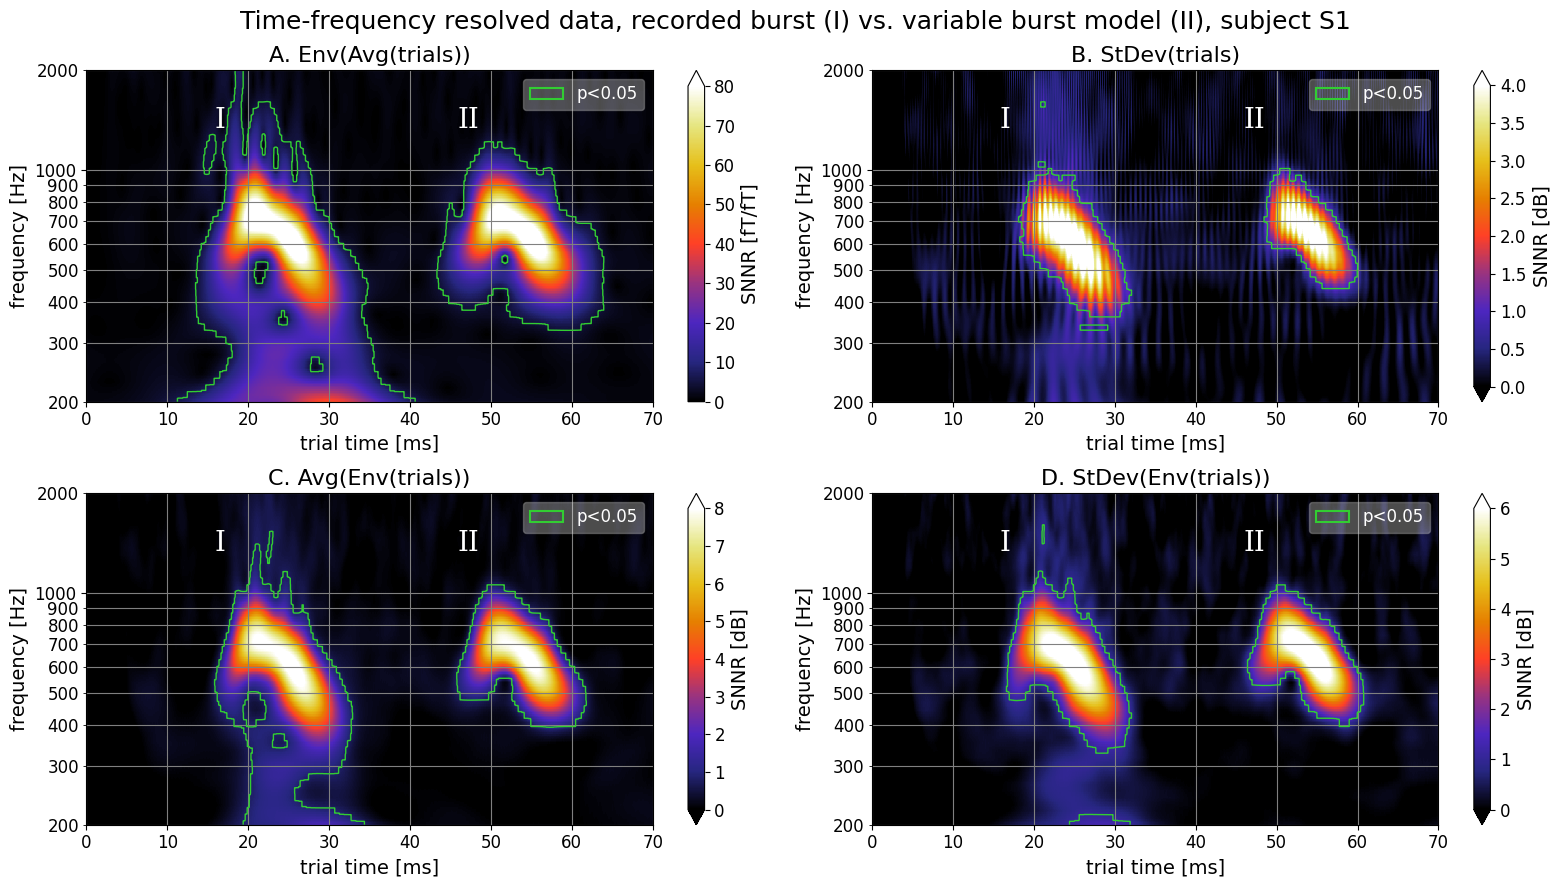

In [29]:
from matplotlib.patches import Patch

rect_patch = Patch(
    facecolor='none',
    edgecolor='limegreen',
    linewidth=1.5,
    label='p<0.05'
)

plt.rcParams['image.cmap'] = 'CMRmap'
fig, axs = plt.subplots(2, 2, figsize=(16, 9))
plt_header('Time-frequency resolved data, recorded burst (I) vs. variable burst model (II), subject ' + subject,
            use_suptitle=True, fontsize=18)

i,j=0,0
data_y = env_avg_out_interp
axs[i][j].set_title('A. Env(Avg(trials))', fontsize=16)
img = axs[i][j].pcolormesh(data_t_st_targ_ms, wanted_frequencies, data_y, vmin=0, vmax=80)
axs[i][j].contour(data_t_st_targ_ms, wanted_frequencies, env_avg_p_val_interp, levels=[0.05],
                  colors='limegreen', linewidths=1)
axs[i][j].grid(visible=True, which='both', c='gray')
axs[i][j].set_ylabel('frequency [Hz]', fontsize=14)
axs[i][j].set_xlabel('trial time [ms]', fontsize=14)
clb = fig.colorbar(img, extend='max')
clb.set_label('SNNR [fT/fT]', fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[i][j].set_yscale('log')
axs[i][j].get_yaxis().set_minor_formatter(plticker.ScalarFormatter())
axs[i][j].get_yaxis().set_major_formatter(plticker.ScalarFormatter())
axs[i][j].set_ylim([200,2000])
axs[i][j].set_xlim([0,70])
axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(10))
axs[i][j].tick_params(which='both', labelsize=12)
axs[i][j].legend(handles=[rect_patch], fontsize=12, labelcolor='white', framealpha=0.3, loc='upper right')

i,j=0,1
data_y = 20*np.log10(np.clip(std_out_interp, sys.float_info.min, None))
axs[i][j].set_title('B. StDev(trials)', fontsize=16)
img = axs[i][j].pcolormesh(data_t_st_targ_ms, wanted_frequencies, data_y, vmin=0, vmax=4)
axs[i][j].contour(data_t_st_targ_ms, wanted_frequencies, std_p_val_interp, levels=[0.05],
                  colors='limegreen', linewidths=1)
axs[i][j].grid(visible=True, which='both', c='gray')
axs[i][j].set_ylabel('frequency [Hz]', fontsize=14)
axs[i][j].set_xlabel('trial time [ms]', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label('SNNR [dB]', fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[i][j].set_yscale('log')
axs[i][j].get_yaxis().set_minor_formatter(plticker.ScalarFormatter())
axs[i][j].get_yaxis().set_major_formatter(plticker.ScalarFormatter())
axs[i][j].set_ylim([200,2000])
axs[i][j].set_xlim([0,70])
axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(10))
axs[i][j].tick_params(which='both', labelsize=12)
axs[i][j].legend(handles=[rect_patch], fontsize=12, labelcolor='white', framealpha=0.3, loc='upper right')


i,j=1,0
data_y = 20*np.log10(np.clip(avg_env_out_interp, sys.float_info.min, None))
axs[i][j].set_title('C. Avg(Env(trials))', fontsize=16)
img = axs[i][j].pcolormesh(data_t_st_targ_ms, wanted_frequencies, data_y, vmin=0, vmax=8)
axs[i][j].contour(data_t_st_targ_ms, wanted_frequencies, avg_env_p_val_interp, levels=[0.05],
                  colors='limegreen', linewidths=1)
axs[i][j].grid(visible=True, which='both', c='gray')
axs[i][j].set_ylabel('frequency [Hz]', fontsize=14)
axs[i][j].set_xlabel('trial time [ms]', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label('SNNR [dB]', fontsize=14)
clb.ax.tick_params(labelsize=12)
clb.ax.yaxis.set_major_locator(plticker.MultipleLocator(1))
axs[i][j].set_yscale('log')
axs[i][j].get_yaxis().set_minor_formatter(plticker.ScalarFormatter())
axs[i][j].get_yaxis().set_major_formatter(plticker.ScalarFormatter())
axs[i][j].set_ylim([200,2000])
axs[i][j].set_xlim([0,70])
axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(10))
axs[i][j].tick_params(which='both', labelsize=12)
axs[i][j].legend(handles=[rect_patch], fontsize=12, labelcolor='white', framealpha=0.3, loc='upper right')


i,j=1,1
data_y = 20*np.log10(np.clip(std_env_out_interp, sys.float_info.min, None))
axs[i][j].set_title('D. StDev(Env(trials))', fontsize=16)
img = axs[i][j].pcolormesh(data_t_st_targ_ms, wanted_frequencies, data_y, vmin=0, vmax=6)
axs[i][j].contour(data_t_st_targ_ms, wanted_frequencies, std_env_p_val_interp, levels=[0.05],
                  colors='limegreen', linewidths=1)
axs[i][j].grid(visible=True, which='both', c='gray')
axs[i][j].set_ylabel('frequency [Hz]', fontsize=14)
axs[i][j].set_xlabel('trial time [ms]', fontsize=14)
clb = fig.colorbar(img, extend='both')
clb.set_label('SNNR [dB]', fontsize=14)
clb.ax.tick_params(labelsize=12)
axs[i][j].set_yscale('log')
axs[i][j].get_yaxis().set_minor_formatter(plticker.ScalarFormatter())
axs[i][j].get_yaxis().set_major_formatter(plticker.ScalarFormatter())
axs[i][j].set_ylim([200,2000])
axs[i][j].set_xlim([0,70])
axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(10))
axs[i][j].tick_params(which='both', labelsize=12)
axs[i][j].legend(handles=[rect_patch], fontsize=12, labelcolor='white', framealpha=0.3, loc='upper right')

for k in range(4):

    if(k==0):
        i,j = 0,0
    elif(k==1):
        i,j = 0,1
    elif(k==2):
        i,j = 1,0
    elif(k==3):
        i,j = 1,1

    axs[i][j].text(0.235, 0.85, 'I', fontsize=20, fontname='serif',
                ha='center', va='center', transform=axs[i][j].transAxes, c='white')

    axs[i][j].text(0.675, 0.85, 'II', fontsize=20, fontname='serif',
                ha='center', va='center', transform=axs[i][j].transAxes, c='white')

fig.tight_layout()
plt_show_save_fig(subject)